# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [3]:
df = pd.read_csv('CHURN_TELECON_MOD15_TAREFA15_2_parte.csv', delimiter=',')
df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,8191-XWSZG,Female,0,No,No,52,Yes,No internet service,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No
5,9959-WOFKT,Male,0,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),71.45,7382.25,No
6,4190-MFLUW,Female,0,Yes,Yes,10,Yes,DSL,No,Yes,No,Month-to-month,Credit card (automatic),71.45,528.35,Yes
7,4183-MYFRB,Female,0,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,1862.90,No
8,8779-QRDMV,Male,1,No,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,71.45,39.65,Yes
9,1680-VDCWW,Male,0,Yes,No,12,Yes,No internet service,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),71.45,202.25,No


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [6]:
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2488.000000,2488.000000,2488.000000,2488.000000
mean,0.161576,32.352090,66.342564,2290.087178
std,0.368135,24.636885,28.051718,2264.585643
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,45.400000,402.337500
50%,0.000000,29.000000,71.450000,1402.900000
75%,0.000000,56.000000,87.712500,3867.162500
max,1.000000,72.000000,118.650000,8564.750000


In [ ]:
'''
questão letra a)
Observando a função descreibe, mais de 16% dos clientes são idosos;
o tempo médio que os clientes permanecem com a empresa é de 32 meses;
a média de pagamentos mensais é de aproximadamente 66 reais;
e 50% por cento dos clientes pagam até o valor da mediana de aproximadamente 71 reais.
'''

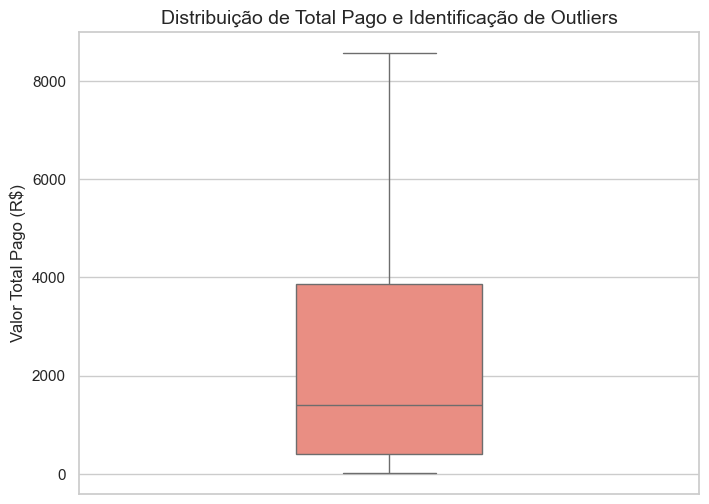

In [12]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Boxplot vertical com melhorias visuais
sns.boxplot(y=df['Total_Pago'], color='salmon', width=0.3, fliersize=5)

# Adicionando elementos informativos
plt.title('Distribuição de Total Pago e Identificação de Outliers', fontsize=14)
plt.ylabel('Valor Total Pago (R$)', fontsize=12)

plt.show()

In [ ]:
'''
questão letra b)
A váriavel totoal pago possui um outliers quando observamos o menor e o maior valor registrado;
'''

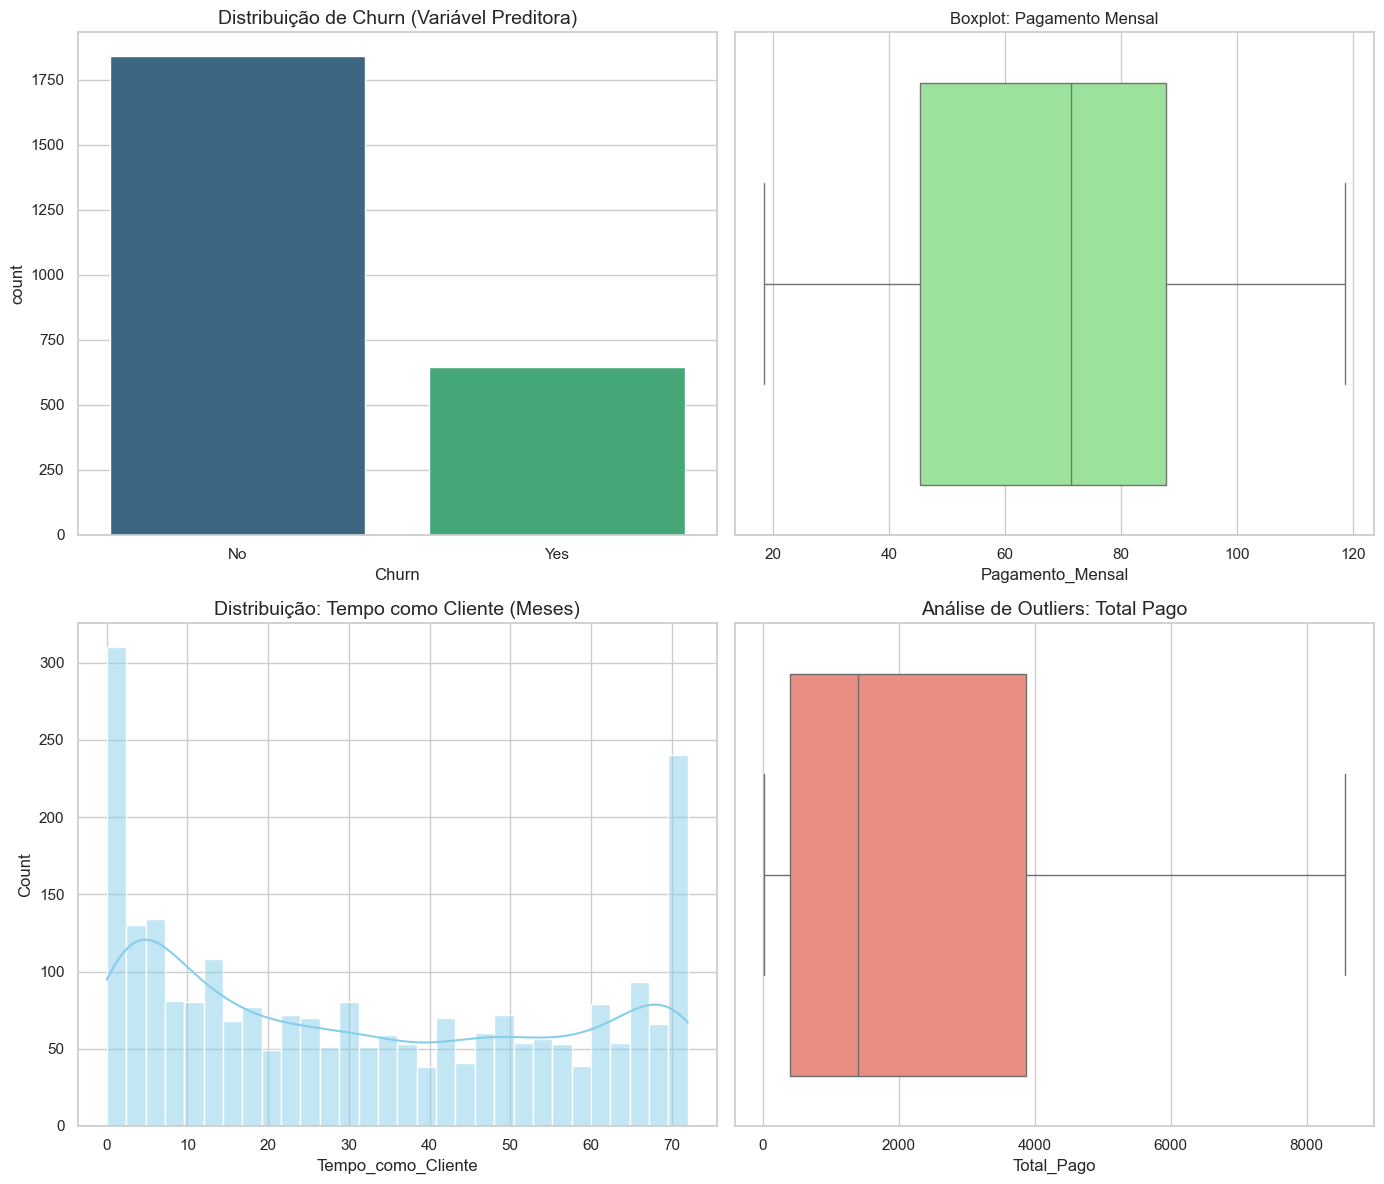

Quantidade de outliers em Total_Pago: 0
Limite Superior para Outliers: R$ 9064.40


In [13]:
# 1. Configuração de estilo e layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# A) Distribuição de Churn (Target) - Adicionado rótulos de contagem
sns.countplot(data=df, x='Churn', ax=axes[0,0], palette='viridis', hue='Churn', legend=False)
axes[0,0].set_title('Distribuição de Churn (Variável Preditora)', fontsize=14)

# 2. NOVO: Boxplot de Pagamento Mensal (Identificação de Outliers)
sns.boxplot(data=df, x='Pagamento_Mensal', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Boxplot: Pagamento Mensal', fontsize=12)

# C) Histograma de Tempo como Cliente - Adicionado KDE para ver a densidade
sns.histplot(data=df, x='Tempo_como_Cliente', bins=30, kde=True, ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Distribuição: Tempo como Cliente (Meses)', fontsize=14)

# D) Total Pago com Identificação de Outliers
sns.boxplot(data=df, x='Total_Pago', ax=axes[1,1], color='salmon', fliersize=5)
axes[1,1].set_title('Análise de Outliers: Total Pago', fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
'''
questão letra c)
No gráfico 2 e no gráfico 4, pagamento mensal e total de pagamentos
é perceptivel os valores acima da haste superior de valores.
'''

In [17]:
# Verificar balanceamento
print("IDOSO:")
print(df['Idoso'].value_counts(normalize=True).round(3) * 100)

print("\nCHURN:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

print("\nCASADO:")
print(df['Casado'].value_counts(normalize=True).round(3) * 100)

IDOSO:
Idoso
0    83.8
1    16.2
Name: proportion, dtype: float64

CHURN:
Churn
No     74.0
Yes    26.0
Name: proportion, dtype: float64

CASADO:
Casado
No     50.7
Yes    49.3
Name: proportion, dtype: float64


In [ ]:
'''
questão letra d)
As variáveis de quantidade de idosos e quem efetua churn, estão desequilibradas, sendo 
a quantidade de idosos a que é mais discrepante das demais idades
'''

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [14]:
# --- Cálculo Matemático de Outliers para 'Total_Pago' ---
Q1 = df['Total_Pago'].quantile(0.25)
Q3 = df['Total_Pago'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df[df['Total_Pago'] > limite_superior]
print(f"Quantidade de outliers em Total_Pago: {len(outliers)}")
print(f"Limite Superior para Outliers: R$ {limite_superior:.2f}")

Quantidade de outliers em Total_Pago: 0
Limite Superior para Outliers: R$ 9064.40


# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

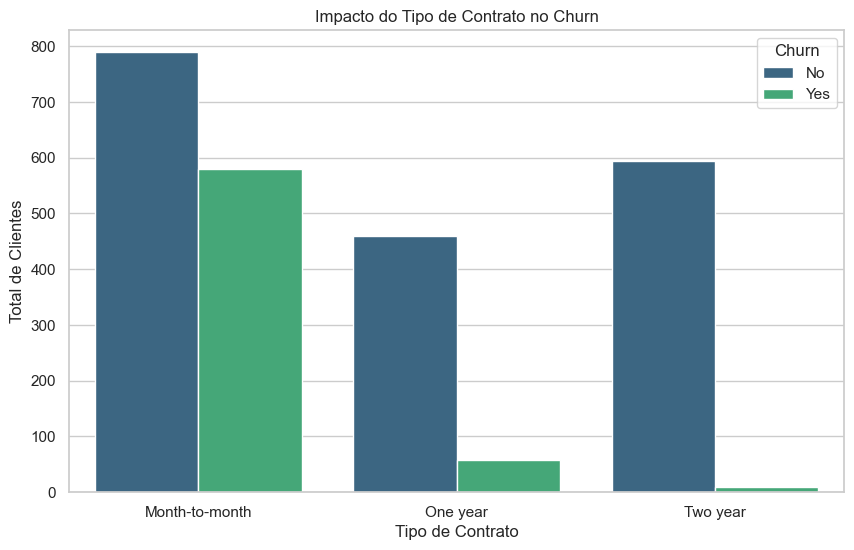

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Tipo_Contrato', hue='Churn', palette='viridis')
plt.title('Impacto do Tipo de Contrato no Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Total de Clientes')
plt.show()

In [ ]:
'''
contratos mensais são mais voláteis que os de longa duração como no caso o de 2 anos
'''

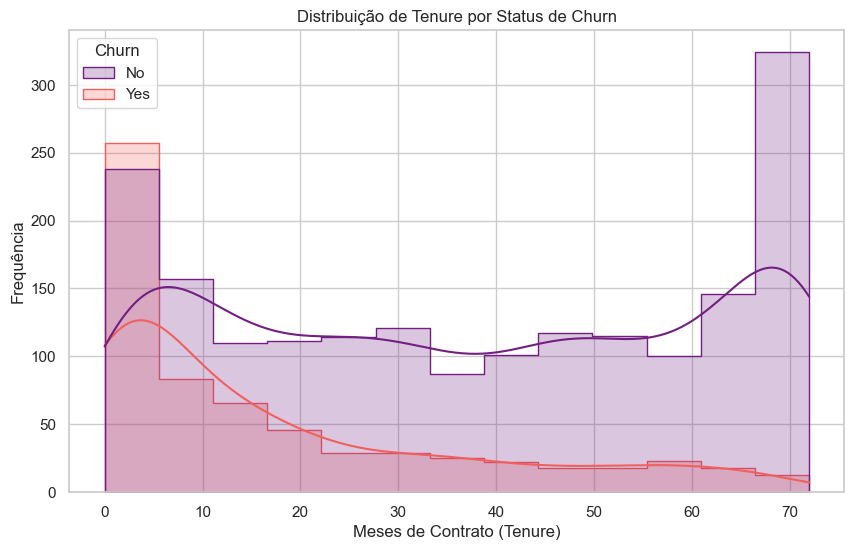

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Tempo_como_Cliente', hue='Churn', kde=True, element="step", palette='magma')
plt.title('Distribuição de Tenure por Status de Churn')
plt.xlabel('Meses de Contrato (Tenure)')
plt.ylabel('Frequência')
plt.show()

In [ ]:
'''
aqui percebe-se quanto mais tempo o cliente fica na 
marca maior é a lealdade e assume a responsalidade de continuar com os serviços
'''

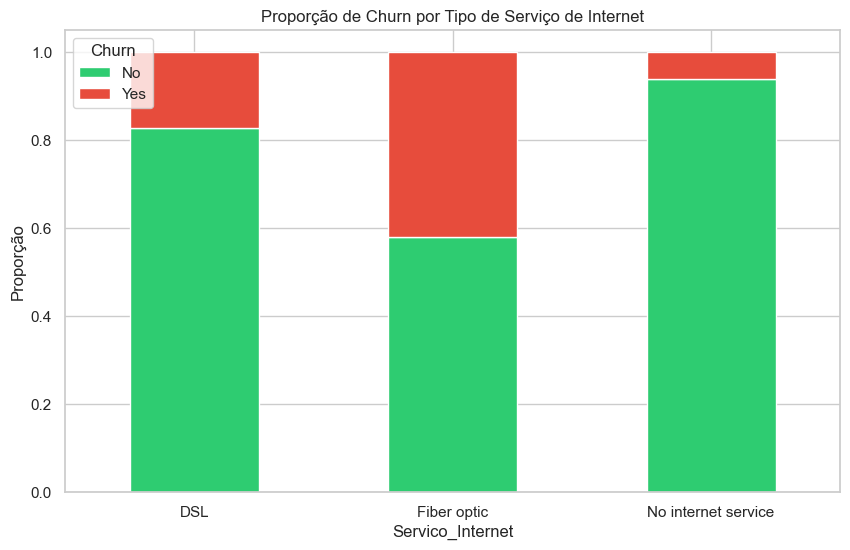

In [20]:
# Gráfico de barras normalizado para ver a proporção (taxa) de churn
plt.figure(figsize=(10, 6))
props = df.groupby("Servico_Internet")['Churn'].value_counts(normalize=True).unstack()
props.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Proporção de Churn por Tipo de Serviço de Internet')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.show()

In [ ]:
'''
Usuários de Fiber optic possuem taxa de Churn mais elevada 
que usuários de DSL.
Isso sugere insatisfação com o preço premium ou problemas 
de estabilidade técnica no serviço de fibra.
'''

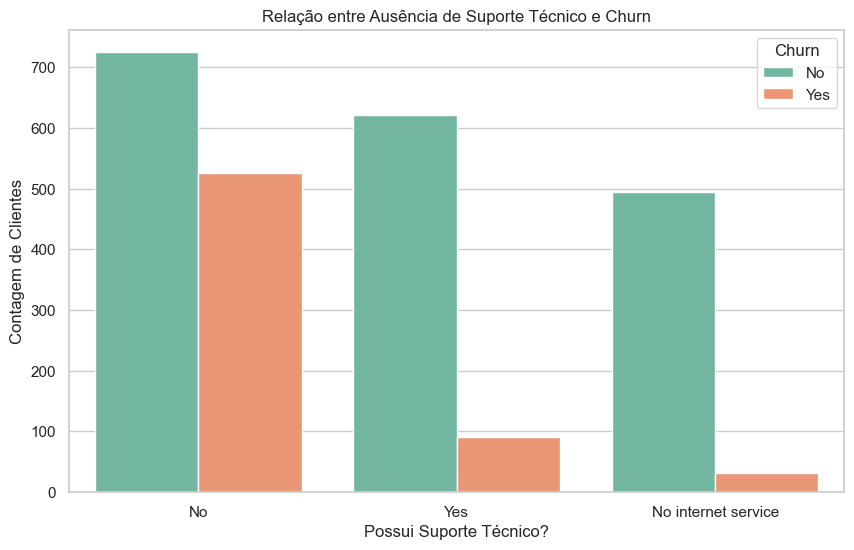

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Suporte_Tecnico', hue='Churn', palette='Set2')
plt.title('Relação entre Ausência de Suporte Técnico e Churn')
plt.xlabel('Possui Suporte Técnico?')
plt.ylabel('Contagem de Clientes')
plt.show()

In [ ]:
'''
Clientes sem Suporte Técnico (Technical Support) cancelam com muito mais frequência.
O suporte atua como um serviço de valor agregado que aumenta a percepção de utilidade
e resolve atritos que gerariam o cancelamento.
'''

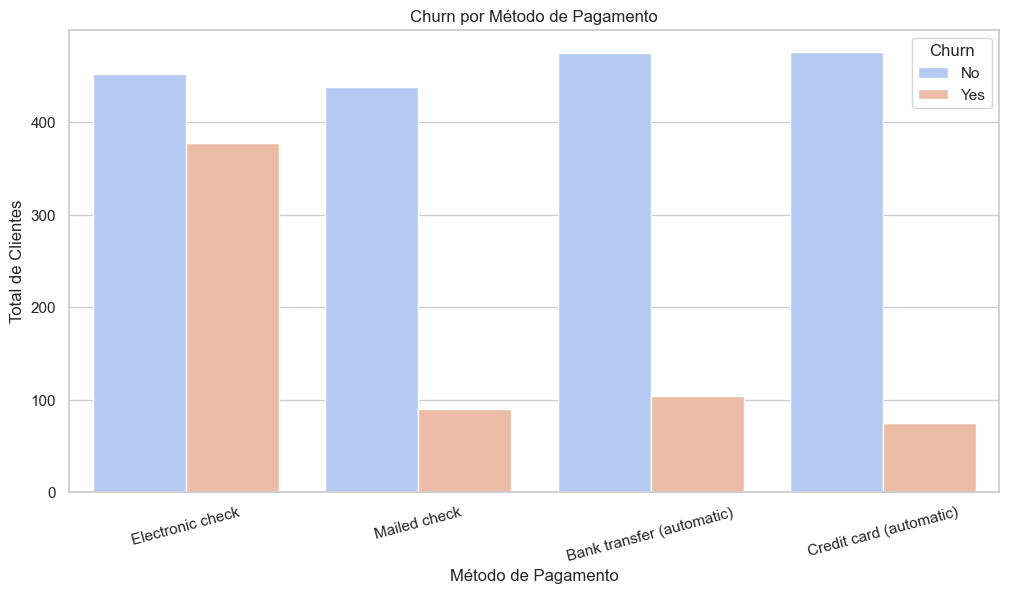

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='coolwarm')
plt.title('Churn por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Total de Clientes')
plt.xticks(rotation=15)
plt.show()

In [ ]:
'''
O método Electronic check está fortemente associado ao Churn. 
Métodos automáticos (Cartão de Crédito ou Transferência Bancária) 
apresentam retenção significativamente maior,
provavelmente pela redução de falhas de pagamento e menor fricção mensal.
'''

/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_1065/3300708105.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


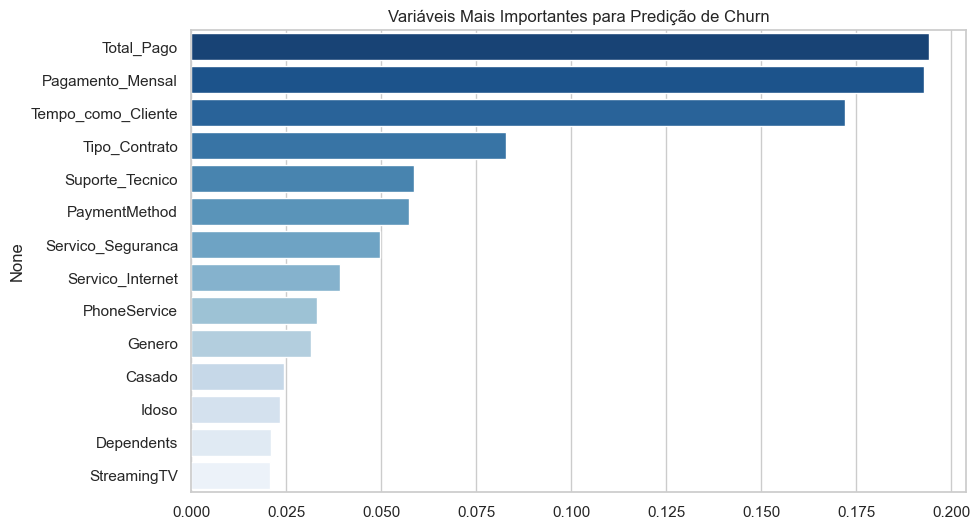

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Cópia para encoding rápido
df_ml = df.copy().drop('customerID', axis=1)
le = LabelEncoder()

for col in df_ml.select_dtypes(include=['object']).columns:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Variáveis Mais Importantes para Predição de Churn')
plt.show()

In [ ]:
'''
As variáveis identificadas como preditores primários para a modelagem de Churn são:

Tipo_Contrato: O fator determinante mais forte; contratos mensais são voláteis.

Tempo_como_Cliente: Define o estágio de maturação e lealdade do usuário.

Suporte_Tecnico / Servico_Seguranca: A ausência desses serviços correlaciona-se com baixa retenção.

Pagamento_Mensal: Valores elevados sem serviços de retenção acoplados aumentam o risco.

Servico_Internet: O tipo de tecnologia contratada dita a sensibilidade ao preço e qualidade.
'''